# Estimate hospital burden

Distribute each grid cell’s population across its top-k reachable hospitals using distance-decay weights, then estimate the effective population burden on each hospital.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    CRS_WGS84,
    FILES,
    DISTANCE_DECAY_ALPHA,
    ensure_project_dirs,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

===== CONFIG =====
City: Nairobi
BBOX: {'lon_min': 36.6, 'lat_min': -1.5, 'lon_max': 37.1, 'lat_max': -1.1}
Grid Size: 1000 m
Top-K Hospitals: 3
Alpha: 1.5
Beta: 1.0
HRSL Path: /Users/suvo/Projects/urban-healthcare/data/raw/population/hrsl_kenya.tif


In [4]:
multi_access = gpd.read_parquet(FILES["multi_access"])
hospitals = gpd.read_parquet(FILES["hospitals"])

multi_access_long_path = Path(FILES["multi_access"]).parent / "multi_access_long.parquet"
multi_access_long = pd.read_parquet(multi_access_long_path)

print("Grid cells:", len(multi_access))
print("Hospitals:", len(hospitals))
print("Rows in long table:", len(multi_access_long))

Grid cells: 2520
Hospitals: 326
Rows in long table: 7560


In [5]:
multi_access[["grid_id", "population", "nearest_hospital_distance_m", "multi_access_score"]].head()

,grid_id,population,nearest_hospital_distance_m,multi_access_score
0,g_00000,0.000000,18919.701825,8.140083e-07
1,g_00001,13.913320,19302.596780,7.939942e-07
2,g_00002,13.913320,19302.596780,7.939942e-07
3,g_00003,16.695984,21495.756410,7.207551e-07
4,g_00004,91.827912,20307.217036,7.750054e-07


In [6]:
# Use the same softened distance decay as Notebook 06
DISTANCE_FLOOR_M = 500.0

multi_access_long["raw_weight"] = 1.0 / (
    (multi_access_long["distance_m"] + DISTANCE_FLOOR_M) ** DISTANCE_DECAY_ALPHA
)

multi_access_long.head()

,grid_id,hospital_id,hospital_node,rank,distance_m,distance_decay,raw_weight
0,g_00000,h_0252,2482452771,1,18919.701825,3.695185e-07,3.695185e-07
1,g_00000,h_0160,6330960585,2,24042.362610,2.600911e-07,2.600911e-07
2,g_00000,h_0253,703562780,3,30367.019545,1.843987e-07,1.843987e-07
3,g_00001,h_0252,2482452771,1,19302.596780,3.588532e-07,3.588532e-07
4,g_00001,h_0160,6330960585,2,24425.257564,2.541210e-07,2.541210e-07


In [7]:
# Normalize weights within each grid cell so they sum to 1
weight_sums = (
    multi_access_long.groupby("grid_id", as_index=False)["raw_weight"]
    .sum()
    .rename(columns={"raw_weight": "weight_sum"})
)

multi_access_long = multi_access_long.merge(weight_sums, on="grid_id", how="left")
multi_access_long["weight_ij"] = multi_access_long["raw_weight"] / multi_access_long["weight_sum"]

multi_access_long[["grid_id", "hospital_id", "distance_m", "raw_weight", "weight_ij"]].head()

,grid_id,hospital_id,distance_m,raw_weight,weight_ij
0,g_00000,h_0252,18919.701825,3.695185e-07,0.453949
1,g_00000,h_0160,24042.362610,2.600911e-07,0.319519
2,g_00000,h_0253,30367.019545,1.843987e-07,0.226532
3,g_00001,h_0252,19302.596780,3.588532e-07,0.451959
4,g_00001,h_0160,24425.257564,2.541210e-07,0.320054


In [8]:
# Bring in population from the grid table
multi_access_long = multi_access_long.merge(
    multi_access[["grid_id", "population"]],
    on="grid_id",
    how="left"
)

multi_access_long["assigned_population"] = (
    multi_access_long["weight_ij"] * multi_access_long["population"]
)

multi_access_long[["grid_id", "hospital_id", "population", "weight_ij", "assigned_population"]].head()

,grid_id,hospital_id,population,weight_ij,assigned_population
0,g_00000,h_0252,0.00000,0.453949,0.000000
1,g_00000,h_0160,0.00000,0.319519,0.000000
2,g_00000,h_0253,0.00000,0.226532,0.000000
3,g_00001,h_0252,13.91332,0.451959,6.288256
4,g_00001,h_0160,13.91332,0.320054,4.453013


In [9]:
# Aggregate burden to hospitals
hospital_burden = (
    multi_access_long.groupby("hospital_id", as_index=False)
    .agg(
        estimated_burden=("assigned_population", "sum"),
        contributing_cells=("grid_id", "nunique"),
        mean_distance_m=("distance_m", "mean")
    )
)

hospital_burden.head()

,hospital_id,estimated_burden,contributing_cells,mean_distance_m
0,h_0000,3410.565176,1,639.806454
1,h_0003,5136.538351,4,1649.433373
2,h_0004,1751.635142,1,901.656831
3,h_0006,18708.241517,1,0.000000
4,h_0008,7535.277939,1,532.730467


In [10]:
# Build a hospital lookup from the original hospital table
hospitals = hospitals.reset_index(drop=True).copy()
hospitals["hospital_id"] = [f"h_{i:04d}" for i in range(len(hospitals))]

hospital_burden_gdf = hospitals.merge(
    hospital_burden,
    on="hospital_id",
    how="inner"
)

print("Hospitals with burden estimates:", len(hospital_burden_gdf))
hospital_burden_gdf.head()

Hospitals with burden estimates: 228


,geometry,amenity,name,operator,healthcare,hospital_id,estimated_burden,contributing_cells,mean_distance_m
0,POINT (4097889.577 -140694.165),hospital,M. P. Shah Hospital,NaN,hospital,h_0000,3410.565176,1,639.806454
1,POINT (4095313.043 -145532.838),hospital,St Augustus Medical Clinic,NaN,hospital,h_0003,5136.538351,4,1649.433373
2,POINT (4094134.292 -146723.946),hospital,Wema Clinic,NaN,hospital,h_0004,1751.635142,1,901.656831
3,POINT (4095355.367 -145616.661),hospital,Marie Stopes Clinic,NaN,hospital,h_0006,18708.241517,1,0.000000
4,POINT (4094719.443 -145461.775),hospital,Mareba Medical Clinic,NaN,hospital,h_0008,7535.277939,1,532.730467


In [11]:
print(hospital_burden_gdf["estimated_burden"].describe())

count       228.000000
mean      33026.738827
std       34833.911235
min         996.978195
25%        9455.353299
50%       19103.809694
75%       47952.231126
max      177746.931741
Name: estimated_burden, dtype: float64


In [12]:
top_burden = hospital_burden_gdf.sort_values("estimated_burden", ascending=False).head(15)

top_burden[["hospital_id", "name", "estimated_burden", "contributing_cells", "mean_distance_m"]]

,hospital_id,name,estimated_burden,contributing_cells,mean_distance_m
127,h_0155,bripa hospital,177746.931741,18,2715.267658
118,h_0145,St Peters Orthopedic & Surgical Sepcialty Cent...,171734.853653,23,2946.046736
222,h_0273,Hurlingham Medical Center,162142.304755,15,2788.646920
72,h_0098,Health Gate Hospital,161241.093490,10,1926.166503
33,h_0049,lema dispensing chemist,160484.274137,15,2559.703107
201,h_0252,Baraka Medical Centre,149740.363452,361,12654.593468
204,h_0255,Wendani health services,146991.730368,10,2022.150496
182,h_0225,Jamaa Mission,115069.439528,30,4734.053480
113,h_0140,Utawala Health Center,108359.271065,243,9855.800748
149,h_0178,Athi River Shalom Community Hospital,100265.710540,76,6660.651354


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/07_hospital_burden.png


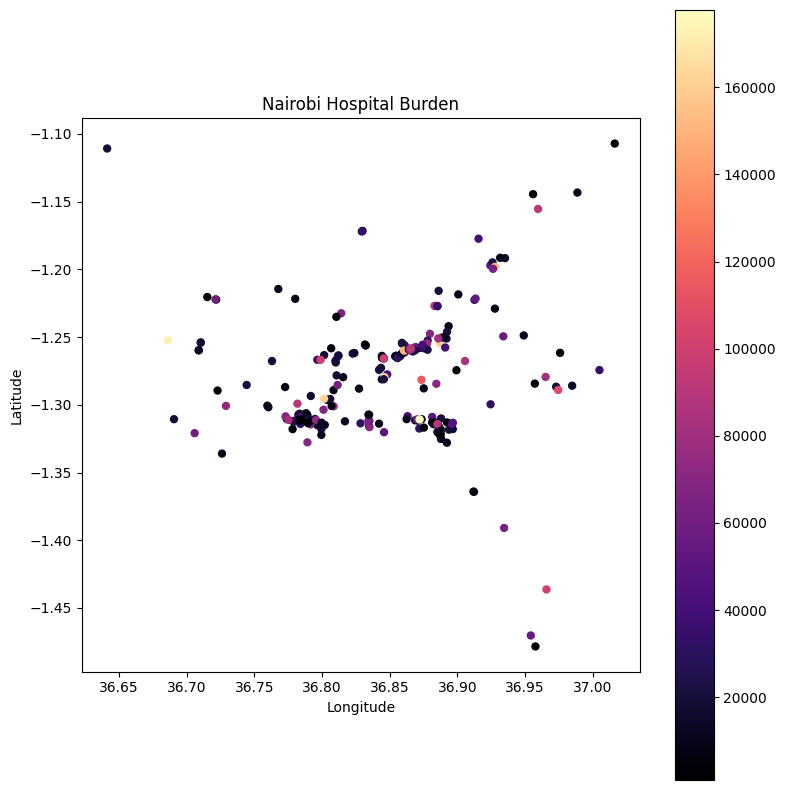

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

hospital_burden_wgs84 = hospital_burden_gdf.to_crs(CRS_WGS84)

hospital_burden_wgs84.plot(
    column="estimated_burden",
    ax=ax,
    cmap="magma",
    legend=True,
    markersize=25
)

ax.set_title(f"{CITY_NAME} Hospital Burden")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "07_hospital_burden.png")
plt.show()

Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/07_top15_hospital_burden_bar.png


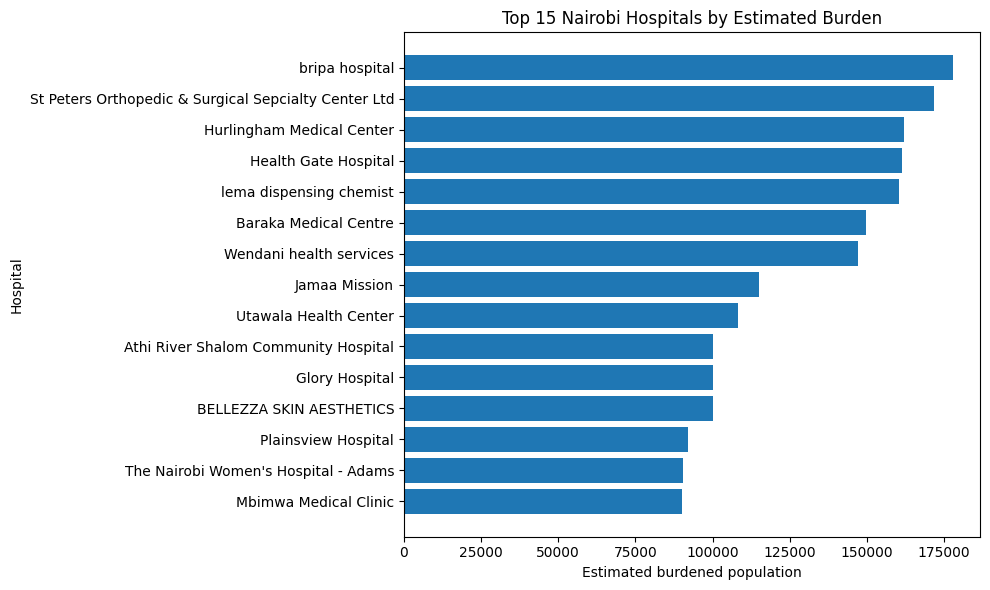

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

top_burden_plot = top_burden.sort_values("estimated_burden", ascending=True)

ax.barh(top_burden_plot["name"].fillna(top_burden_plot["hospital_id"]), top_burden_plot["estimated_burden"])

ax.set_title(f"Top 15 {CITY_NAME} Hospitals by Estimated Burden")
ax.set_xlabel("Estimated burdened population")
ax.set_ylabel("Hospital")
plt.tight_layout()

savefig(fig, "07_top15_hospital_burden_bar.png")
plt.show()

In [15]:
hospital_burden_gdf.to_parquet(FILES["hospital_burden"], index=False)
print("Saved hospital burden to:", FILES["hospital_burden"])

Saved hospital burden to: /Users/suvo/Projects/urban-healthcare/data/processed/hospital_burden.parquet


In [16]:
multi_access_long.to_parquet(multi_access_long_path, index=False)
print("Updated long multi-access table with weights:", multi_access_long_path)

Updated long multi-access table with weights: /Users/suvo/Projects/urban-healthcare/data/processed/multi_access_long.parquet


In [17]:
hospital_burden_gdf["estimated_burden"].sum()

np.float64(7530096.452538)